In [ ]:
# IMPORTS

# pip install scikit-learn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn import metrics
from ydata_profiling import ProfileReport


In [47]:
df = pd.read_csv('lego_sets.csv')
df.head()

,ages,list_price,num_reviews,piece_count,play_star_rating,prod_desc,prod_id,prod_long_desc,review_difficulty,set_name,star_rating,theme_name,val_star_rating,country
0,6-12,29.99,2.0,277.0,4.0,Catapult into action and take back the eggs fr...,75823.0,Use the staircase catapult to launch Red into ...,Average,Bird Island Egg Heist,4.5,Angry Birds™,4.0,US
1,6-12,19.99,2.0,168.0,4.0,Launch a flying attack and rescue the eggs fro...,75822.0,Pilot Pig has taken off from Bird Island with ...,Easy,Piggy Plane Attack,5.0,Angry Birds™,4.0,US
2,6-12,12.99,11.0,74.0,4.3,Chase the piggy with lightning-fast Chuck and ...,75821.0,Pitch speedy bird Chuck against the Piggy Car....,Easy,Piggy Car Escape,4.3,Angry Birds™,4.1,US
3,12+,99.99,23.0,1032.0,3.6,Explore the architecture of the United States ...,21030.0,Discover the architectural secrets of the icon...,Average,United States Capitol Building,4.6,Architecture,4.3,US
4,12+,79.99,14.0,744.0,3.2,Recreate the Solomon R. Guggenheim Museum® wit...,21035.0,Discover the architectural secrets of Frank Ll...,Challenging,Solomon R. Guggenheim Museum®,4.6,Architecture,4.1,US


### step 0:
creating new interesting columns and fixing current ones


In [48]:
df['country'].unique()

array(['US', 'AU', 'AT', 'BE', 'CA', 'CH', 'CZ', 'DE', 'DN', 'ES', 'FI',
       'FR', 'GB', 'IE', 'IT', 'LU', 'NO', 'NL', 'NZ', 'PL', 'PT'],
      dtype=object)

In [49]:
# This code makes the column 'continent' instead of country, which can be then turned into three separate columns.

country_to_continent = {
    'US': 'North America',
    'CA': 'North America',
    'AU': 'Oceania',
    'NZ': 'Oceania',
    'AT': 'Europe',
    'BE': 'Europe',
    'CH': 'Europe',
    'CZ': 'Europe',
    'DE': 'Europe',
    'DN': 'Europe',   
    'ES': 'Europe',
    'FI': 'Europe',
    'FR': 'Europe',
    'GB': 'Europe',
    'IE': 'Europe',
    'IT': 'Europe',
    'LU': 'Europe',
    'NO': 'Europe',
    'NL': 'Europe',
    'PL': 'Europe',
    'PT': 'Europe',
}

df['continent'] = df['country'].map(country_to_continent)
df = df.drop('country', axis=1)

In [50]:
# Creating a new column 'price_per_brick' for more fun comparisons
# Some legosets might be more expensive even with less bricks than other sets
# Only for analytic purposes, doesn't work in ML

df['price_per_brick'] = df['list_price'] / df['piece_count']
df['price_per_brick'] = df['price_per_brick'].round(2)
df['price_per_brick']


0        0.11
1        0.12
2        0.18
3        0.10
4        0.11
         ... 
12256    0.11
12257    0.11
12258    0.10
12259    0.25
12260    0.11
Name: price_per_brick, Length: 12261, dtype: float64

In [51]:
df['ages'].value_counts()
# Separate this column to two new columns - minAge and maxAge

ages
6-12     1476
7-14     1421
8-14     1180
4-7       957
5-12      911
10+       870
2-5       840
7-12      723
9-14      624
16+       420
8-12      350
4-99      311
12+       298
6-14      233
8+        226
1½-3      213
14+       212
10-21     184
6+        148
10-16     148
1½-5      113
9-16       92
5+         71
11-16      66
9-12       46
12-16      42
4+         21
9+         21
5-8        21
10-14      21
7+          2
Name: count, dtype: int64

In [52]:
import re

def parse_min_age(age_str):
    if pd.isna(age_str):
        return None
    
    age_str = str(age_str).strip()
    age_str = age_str.replace('½', '.5')  # handle fractions like 1½ -> 1.5
    
    # Case: "99+" or "12+"
    if '+' in age_str:
        match = re.search(r'[\d.]+', age_str)
        return float(match.group()) if match else None
    
    # Case: "12-16" (range) -> take the lower bound
    if '-' in age_str:
        parts = age_str.split('-')
        try:
            return float(parts[0].strip())
        except (ValueError, IndexError):
            return None
    
    # Case: single number like "2"
    match = re.fullmatch(r'[\d.]+', age_str)
    if match:
        return float(age_str)
    
    return None

df['min_age'] = df['ages'].apply(parse_min_age)
df = df.drop('ages', axis=1)

In [53]:
df['min_age'].isna().sum()

# Just a sanity check

np.int64(0)

In [74]:
# Mapping the review_difficulty column
review_mapper = {'Very Easy': 0, 'Easy': 1, 'Average': 2, 'Challenging': 3, 'Very Challenging': 4}
df['review_difficulty'] = df['review_difficulty'].map(review_mapper)

### step 1a:

In [54]:
df.dtypes
# They seem to be correct

list_price           float64
num_reviews          float64
piece_count          float64
play_star_rating     float64
prod_desc             object
prod_id              float64
prod_long_desc        object
review_difficulty     object
set_name              object
star_rating          float64
theme_name            object
val_star_rating      float64
continent             object
price_per_brick      float64
min_age              float64
dtype: object

### step 1b:

In [55]:
# # Making the ydata profile

# report = ProfileReport(df,
#     title='Lego sets / Advanced Data Analytics, 2026'
# )
# report.to_file("lego_sets_regression_report.html")

In [56]:
len(df)

12261

In [57]:
df.columns

Index(['list_price', 'num_reviews', 'piece_count', 'play_star_rating',
       'prod_desc', 'prod_id', 'prod_long_desc', 'review_difficulty',
       'set_name', 'star_rating', 'theme_name', 'val_star_rating', 'continent',
       'price_per_brick', 'min_age'],
      dtype='object')

In [58]:
df.head()

,list_price,num_reviews,piece_count,play_star_rating,prod_desc,prod_id,prod_long_desc,review_difficulty,set_name,star_rating,theme_name,val_star_rating,continent,price_per_brick,min_age
0,29.99,2.0,277.0,4.0,Catapult into action and take back the eggs fr...,75823.0,Use the staircase catapult to launch Red into ...,Average,Bird Island Egg Heist,4.5,Angry Birds™,4.0,North America,0.11,6.0
1,19.99,2.0,168.0,4.0,Launch a flying attack and rescue the eggs fro...,75822.0,Pilot Pig has taken off from Bird Island with ...,Easy,Piggy Plane Attack,5.0,Angry Birds™,4.0,North America,0.12,6.0
2,12.99,11.0,74.0,4.3,Chase the piggy with lightning-fast Chuck and ...,75821.0,Pitch speedy bird Chuck against the Piggy Car....,Easy,Piggy Car Escape,4.3,Angry Birds™,4.1,North America,0.18,6.0
3,99.99,23.0,1032.0,3.6,Explore the architecture of the United States ...,21030.0,Discover the architectural secrets of the icon...,Average,United States Capitol Building,4.6,Architecture,4.3,North America,0.10,12.0
4,79.99,14.0,744.0,3.2,Recreate the Solomon R. Guggenheim Museum® wit...,21035.0,Discover the architectural secrets of Frank Ll...,Challenging,Solomon R. Guggenheim Museum®,4.6,Architecture,4.1,North America,0.11,12.0


In [59]:
# dropping unnessary columns, most of these columns are just set names or descriptions of the sets
droppables = ['prod_desc', 'prod_long_desc', 'theme_name', 'set_name']
df = df.drop(droppables, axis=1)

### Step 1c:

In [60]:
df.isna().sum()

list_price              0
num_reviews          1620
piece_count             0
play_star_rating     1775
prod_id                 0
review_difficulty    2055
star_rating          1620
val_star_rating      1795
continent               0
price_per_brick         0
min_age                 0
dtype: int64

In [61]:
# No rows with all rows na
df[df.isna().all(axis=1)]

,list_price,num_reviews,piece_count,play_star_rating,prod_id,review_difficulty,star_rating,val_star_rating,continent,price_per_brick,min_age


In [62]:
df[df.isna().any(axis=1)]

,list_price,num_reviews,piece_count,play_star_rating,prod_id,review_difficulty,star_rating,val_star_rating,continent,price_per_brick,min_age
22,9.9900,1.0,136.0,NaN,41607.0,NaN,5.0,NaN,North America,0.07,10.0
32,19.9900,NaN,209.0,NaN,41610.0,NaN,NaN,NaN,North America,0.10,10.0
48,49.9900,NaN,387.0,NaN,60175.0,NaN,NaN,NaN,North America,0.13,5.0
55,99.9900,1.0,883.0,5.0,60188.0,NaN,5.0,5.0,North America,0.11,7.0
69,39.9900,NaN,297.0,NaN,60172.0,NaN,NaN,NaN,North America,0.13,5.0
...,...,...,...,...,...,...,...,...,...,...,...
12136,36.5878,NaN,104.0,NaN,75537.0,NaN,NaN,NaN,Europe,0.35,8.0
12137,36.5878,NaN,101.0,NaN,75535.0,NaN,NaN,NaN,Europe,0.36,8.0
12196,243.9878,NaN,1967.0,NaN,75181.0,NaN,NaN,NaN,Europe,0.12,14.0
12214,24.3878,1.0,135.0,5.0,42072.0,NaN,5.0,5.0,Europe,0.18,7.0


In [63]:
df_duplicates = df[df.duplicated()]

In [64]:
df_duplicates

,list_price,num_reviews,piece_count,play_star_rating,prod_id,review_difficulty,star_rating,val_star_rating,continent,price_per_brick,min_age
195,9.9900,5.0,143.0,4.6,41599.0,Easy,5.0,5.0,North America,0.07,10.0
196,9.9900,3.0,122.0,2.7,41598.0,Very Easy,4.0,3.0,North America,0.08,10.0
197,9.9900,1.0,135.0,1.0,41600.0,Very Easy,4.0,3.0,North America,0.07,10.0
198,9.9900,2.0,108.0,3.5,41601.0,Easy,5.0,4.0,North America,0.09,10.0
199,19.9900,NaN,209.0,NaN,41610.0,NaN,NaN,NaN,North America,0.10,10.0
...,...,...,...,...,...,...,...,...,...,...,...
12256,36.5878,6.0,341.0,4.4,70609.0,Easy,4.3,4.2,Europe,0.11,7.0
12257,24.3878,8.0,217.0,4.1,70629.0,Easy,3.6,4.1,Europe,0.11,7.0
12258,24.3878,18.0,233.0,4.6,70607.0,Easy,4.6,4.5,Europe,0.10,7.0
12259,12.1878,1.0,48.0,5.0,70628.0,Very Easy,5.0,5.0,Europe,0.25,6.0


In [65]:
df = df.dropna() # Drops 1/10th of the data so not too bad
len(df)

10165

In [66]:
df.duplicated().sum()

np.int64(4275)

In [67]:
df.drop_duplicates()

,list_price,num_reviews,piece_count,play_star_rating,prod_id,review_difficulty,star_rating,val_star_rating,continent,price_per_brick,min_age
0,29.9900,2.0,277.0,4.0,75823.0,Average,4.5,4.0,North America,0.11,6.0
1,19.9900,2.0,168.0,4.0,75822.0,Easy,5.0,4.0,North America,0.12,6.0
2,12.9900,11.0,74.0,4.3,75821.0,Easy,4.3,4.1,North America,0.18,6.0
3,99.9900,23.0,1032.0,3.6,21030.0,Average,4.6,4.3,North America,0.10,12.0
4,79.9900,14.0,744.0,3.2,21035.0,Challenging,4.6,4.1,North America,0.11,12.0
...,...,...,...,...,...,...,...,...,...,...,...
12131,213.4878,6.0,1413.0,4.3,75212.0,Average,4.3,3.7,Europe,0.15,9.0
12145,153.7078,15.0,825.0,4.7,75191.0,Average,4.7,4.3,Europe,0.19,9.0
12193,19.5078,6.0,102.0,4.2,75206.0,Very Easy,4.2,4.3,Europe,0.19,6.0
12194,19.5078,6.0,99.0,4.6,75207.0,Very Easy,5.0,4.4,Europe,0.20,6.0


In [68]:
# df.isna().sum() # Lots of NAs, trying KNNimputer for now

# from sklearn.impute import KNNImputer

# imputer = KNNImputer(n_neighbors=5)

# df = pd.DataFrame(
#     imputer.fit_transform(df),
#     columns=df.columns,
#     index=df.index
# )

# int_cols = ['review_difficulty'] 
# df[int_cols] = df[int_cols].round().astype(int)

## Step 1d.

In [70]:
df.columns

Index(['list_price', 'num_reviews', 'piece_count', 'play_star_rating',
       'prod_id', 'review_difficulty', 'star_rating', 'val_star_rating',
       'continent', 'price_per_brick', 'min_age'],
      dtype='object')

## Step 2a.

In [77]:
import statsmodels.api as sm
from scipy.stats import norm

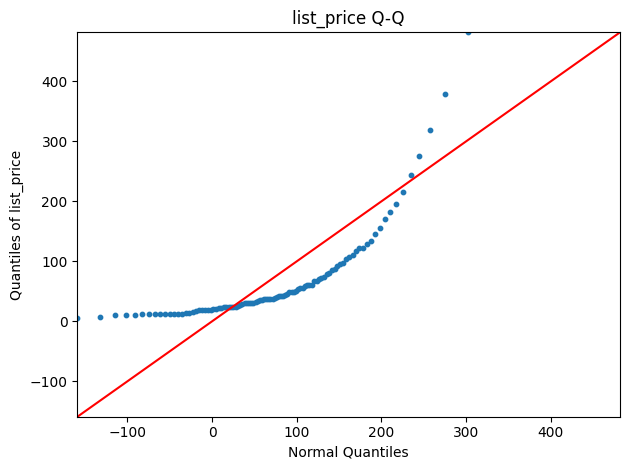

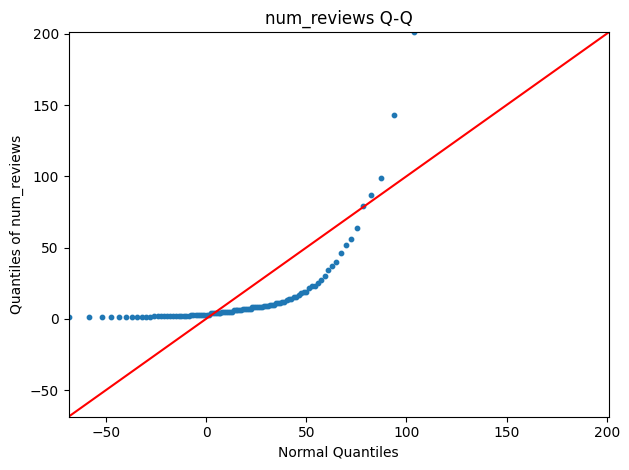

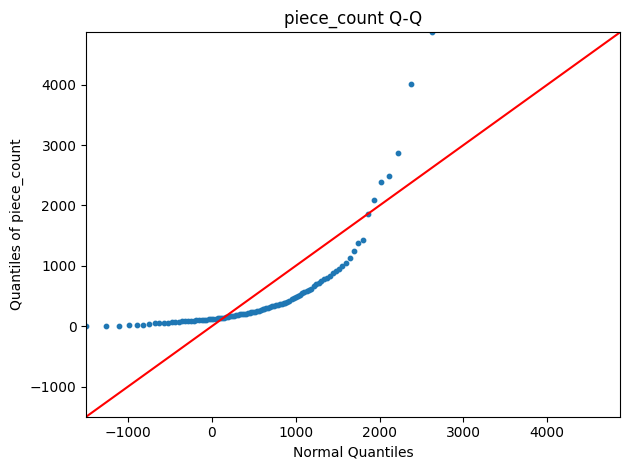

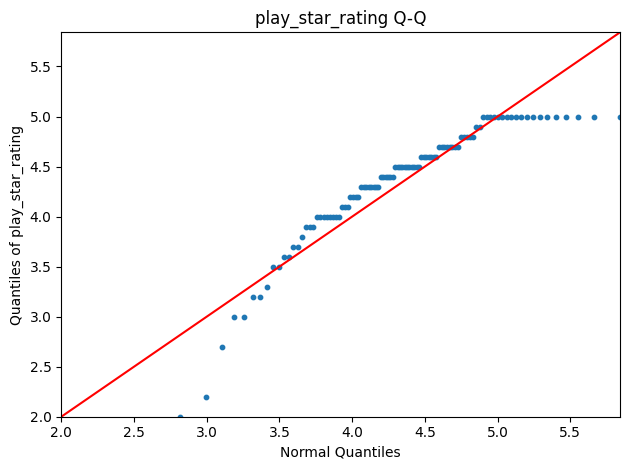

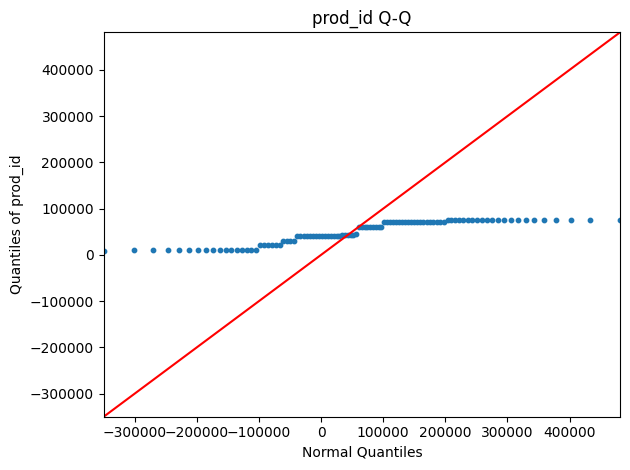

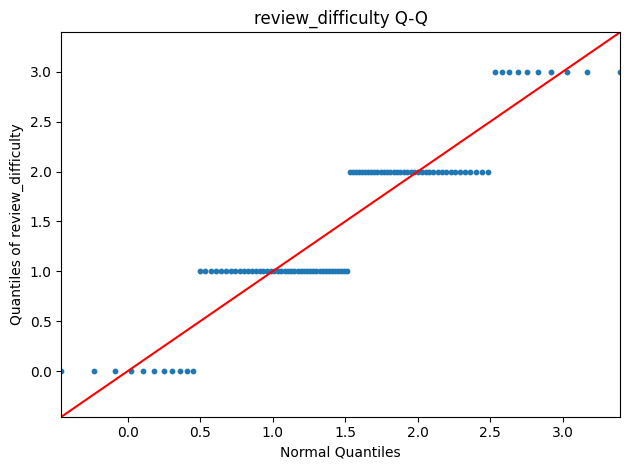

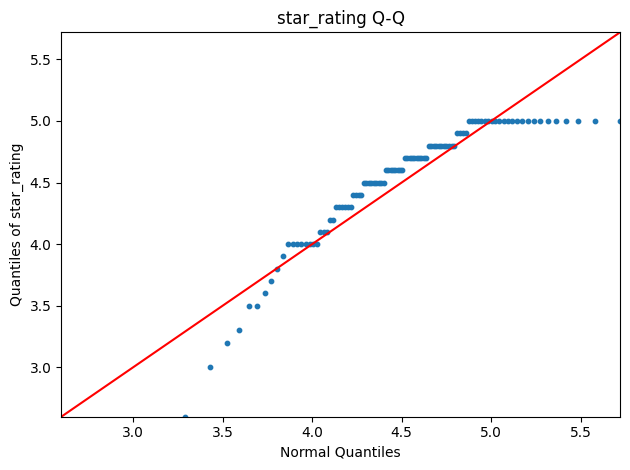

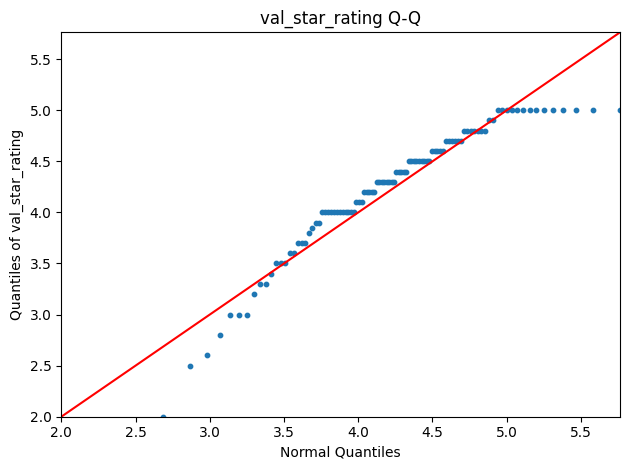

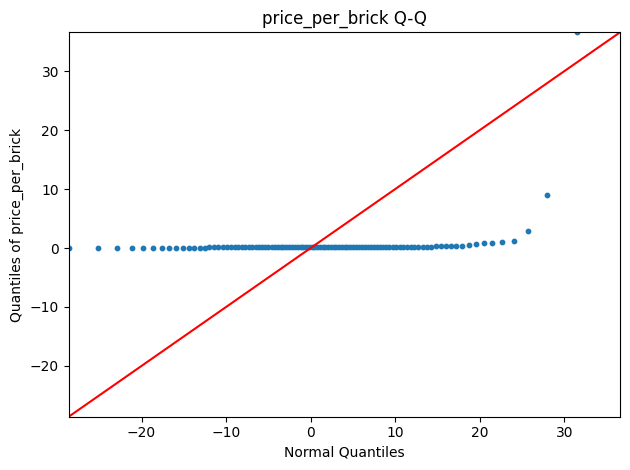

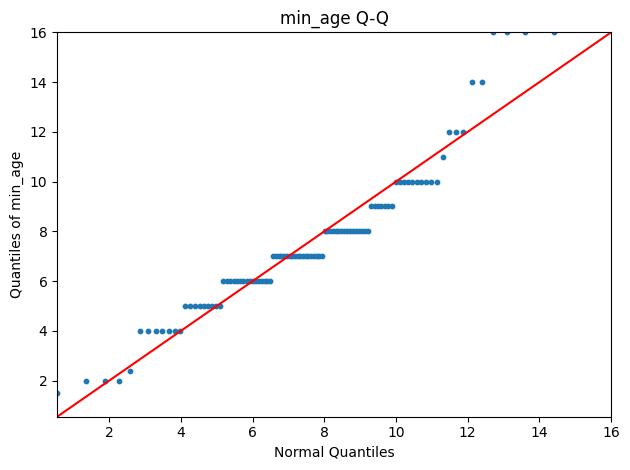

In [78]:
for column in df.columns:

    # Get rid of any non-numerical columns.
    if pd.api.types.is_numeric_dtype(df[column]):

        # Drop missing values in case it causes problems
        values = df[column].dropna()

        # Fit a normal distribution to THIS column's own scale.
        mean, std = values.mean(), values.std()

        # Make 99 percentiles, evenly spaced.
        probs = np.linspace(0.01, 0.99, 99)

        # Copies dataprep's method. take the sample of the quantiles.
        sample_qntls = values.quantile(probs)

        # Theoretical quantiles: what a perfectly normal distribution with
        # the datas mean and std would look like at each %
        theory_qntls = norm.ppf(probs, mean, std)

        # Combine both sets to find a shared min/max.
        vals = np.concatenate([sample_qntls, theory_qntls])
        lo, hi = vals.min(), vals.max()
        fig, ax = plt.subplots()

        # Plot sample quantiles with theoretical quantiles.
        ax.scatter(theory_qntls, sample_qntls, s=10)

        # Draw a diagonal line.
        ax.plot([lo, hi], [lo, hi], color="r")

        # Force both axes to the same range. Makes the 45 degrees fixed.
        ax.set_xlim(lo, hi)
        ax.set_ylim(lo, hi)

        ax.set_title(f"{column} Q-Q")
        ax.set_xlabel("Normal Quantiles")
        ax.set_ylabel(f"Quantiles of {column}")

        plt.tight_layout()
        plt.show()